# Part 3: Variational Autoencoders (VAE)

For this part of the lab, you will implement a VAE. There is some code below which will help you run the learning procedure, however, you will need to complete the definition of the loss function. Start by implementing the encoder and decoder for the VAE. There is a diagram below illustrating what these architectures should look like.

Let's start by loading the Fashion-MNIST dataset again and transforming the data to a flattened tensor.

### Loading the Dataset

In [1]:
%matplotlib inline

import torch
import torchvision
import torchvision.transforms as transforms

batch_size = 256
image_dim = 784 #flattened

# dataset construction
transform = transforms.Compose([
    transforms.ToTensor(), # convert to tensor
    transforms.Lambda(lambda x: x.view(image_dim)) # flatten into vector
    ])

train_set = torchvision.datasets.FashionMNIST(
    root='./data/FashionMNIST'
    ,train=True
    ,download=True
    ,transform=transform
)

train_loader = torch.utils.data.DataLoader(
    train_set, batch_size=batch_size
)

100%|██████████| 26.4M/26.4M [00:01<00:00, 16.7MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 280kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.12MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 11.4MB/s]


## Build a Simple Variational Autoencoder

<img src="https://ecs-vlc.github.io/COMP6258/labs/lab8/VAE_resized.png">

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from tqdm import tqdm
from itertools import chain

import numpy as np

class Encoder(nn.Module):
    '''
    simple encoder with a single hidden dense layer (ReLU activation)
    and linear projections to the diag-Gauss parameters
    '''
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super(Encoder, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_log_sigma2 = nn.Linear(hidden_dim, latent_dim)

    def forward(self, x):
        h = F.relu(self.fc1(x))
        mu = self.fc_mu(h)
        log_sigma2 = self.fc_log_sigma2(h)
        return mu, log_sigma2


class Decoder(nn.Module):
    '''
    simple decoder: single dense hidden layer followed by sigmoid
    '''
    def __init__(self, latent_dim, hidden_dim, output_dim):
        super(Decoder, self).__init__()
        self.fc1 = nn.Linear(latent_dim, hidden_dim)
        self.fc_out = nn.Linear(hidden_dim, output_dim)

    def forward(self, z):
        h = F.relu(self.fc1(z))
        x_recon = torch.sigmoid(self.fc_out(h))
        return x_recon

## You may complete the code below to test your implementation, or alternately, rewrite your own.

#### Once you've trained the network plot some reconstructions side-by-side with the original images and reflect on how good the reconstructions are (or aren't!). Also try generating some random images by sampling the prior and feeding the vectors to the decoder.

In [3]:
import matplotlib.gridspec as gridspec
import os

# Sampling function (using the reparameterisation trick)
def sample(mu, log_sigma2):
    eps = torch.randn(mu.shape[0], mu.shape[1])
    return mu + torch.exp(log_sigma2 / 2) * eps


#parameters
batch_size = 256
embedding_dim = 2
enc_hidden_units = 512
dec_hidden_units = 512
nEpoch = 10

# construct the encoder, decoder and optimiser
enc = Encoder(image_dim, enc_hidden_units, embedding_dim)
dec = Decoder(embedding_dim, dec_hidden_units, image_dim)
optimizer = optim.Adam(chain(enc.parameters(), dec.parameters()), lr=1e-3)

# training loop
for epoch in range(nEpoch):
    losses = []
    trainloader = tqdm(train_loader)

    for i, data in enumerate(trainloader, 0):
        inputs, _ = data

        optimizer.zero_grad()

        mu, log_sigma2 = enc(inputs)
        z = sample(mu, log_sigma2)
        outputs = dec(z)

        # E[log P(X|z)] - as images are binary it makes most sense to use binary cross entropy
        # we need to be a little careful - by default torch averages over every observation
        # (e.g. each  pixel in each image of each batch), whereas we want the average over entire
        # images instead
        recon = F.binary_cross_entropy(outputs, inputs, reduction='sum') / inputs.shape[0]

        kl = 0
        # kl = D_KL(Q(z|X) || P(z|X)) - calculate in closed form
        # Compute the term kl which is then added to the total loss
        # YOUR CODE HERE
        kl = -0.5 * torch.sum(1 + log_sigma2 - mu.pow(2) - torch.exp(log_sigma2)) / inputs.shape[0]

        loss = recon + kl
        loss.backward()
        optimizer.step()

        # keep track of the loss and update the stats
        losses.append(loss.item())
        trainloader.set_postfix(loss=np.mean(losses), epoch=epoch)


    ## Please display some of the generated images in the submitted Notebook
    # YOUR CODE HERE


dec.eval()

n = 16
z = torch.randn(n, embedding_dim)

with torch.no_grad():
    generated = dec(z)



100%|██████████| 235/235 [00:17<00:00, 13.35it/s, epoch=9, loss=264]


NameError: name 'plt' is not defined

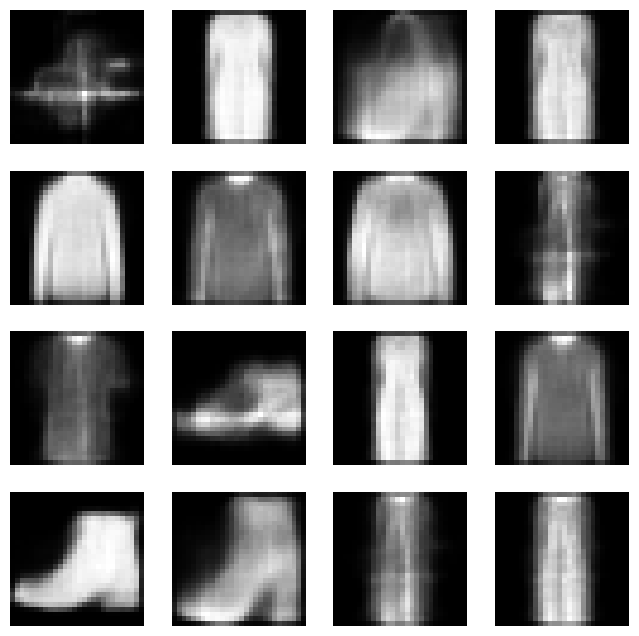

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))

for i in range(n):
    plt.subplot(4, 4, i + 1)
    plt.imshow(generated[i].view(28, 28), cmap='gray')
    plt.axis('off')

plt.show()

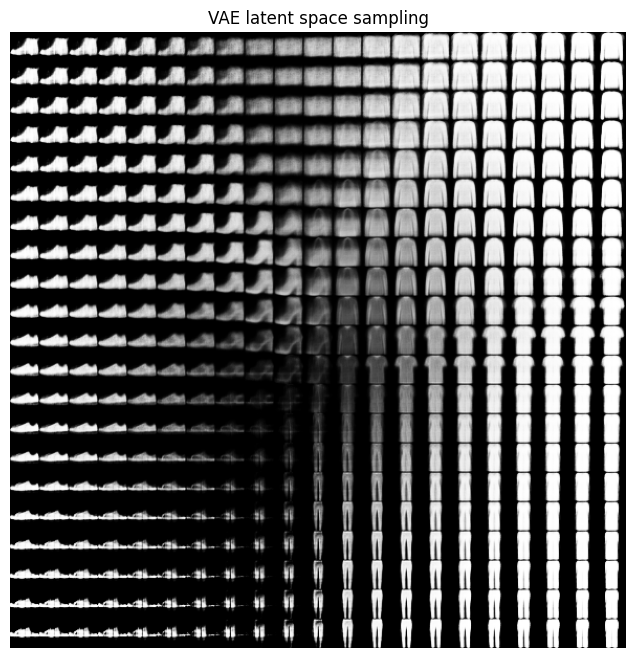

In [5]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# use trained VAE decoder
dec.eval()

n_samples = 21
img_size = 28
canvas_size = n_samples * img_size  # 588

z1_values = np.linspace(-4, 4, n_samples)
z2_values = np.linspace(4, -4, n_samples)

canvas = np.zeros((canvas_size, canvas_size))

with torch.no_grad():
    for i, z2 in enumerate(z2_values):
        for j, z1 in enumerate(z1_values):
            z = torch.tensor([[z1, z2]], dtype=torch.float32)

            generated = dec(z)
            img = generated.view(28, 28).cpu().numpy()

            row_start = i * img_size
            row_end = row_start + img_size
            col_start = j * img_size
            col_end = col_start + img_size

            canvas[row_start:row_end, col_start:col_end] = img

plt.figure(figsize=(8, 8))
plt.imshow(canvas, cmap='gray')
plt.axis('off')
plt.title("VAE latent space sampling")
plt.show()

plt.imsave("vae_latent_space_sampling.png", canvas, cmap='gray')

100%|██████████| 235/235 [00:10<00:00, 22.23it/s, epoch=9, loss=310]


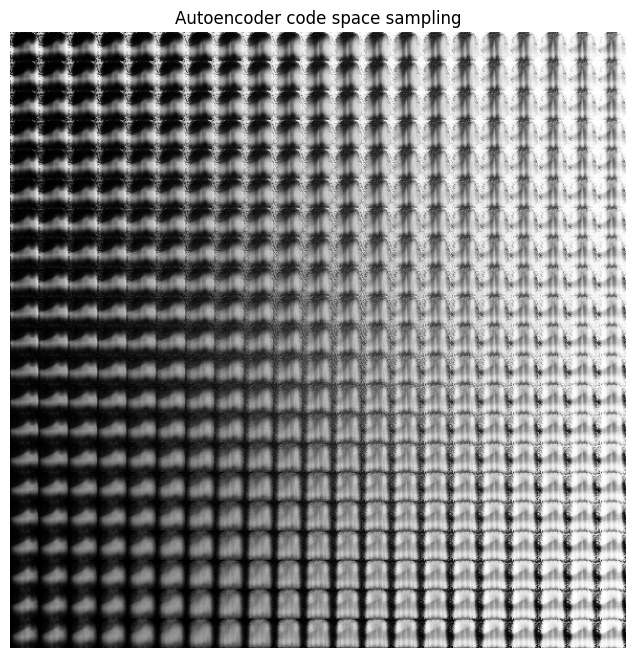

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

from itertools import chain
from tqdm import tqdm


# =========================
# 1. Define 2D Autoencoder
# =========================

class AE_Encoder(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super(AE_Encoder, self).__init__()
        self.fc = nn.Linear(input_dim, latent_dim)

    def forward(self, x):
        z = self.fc(x)
        return z


class AE_Decoder(nn.Module):
    def __init__(self, latent_dim, output_dim):
        super(AE_Decoder, self).__init__()
        self.fc = nn.Linear(latent_dim, output_dim)

    def forward(self, z):
        x_recon = torch.sigmoid(self.fc(z))
        return x_recon


# =========================
# 2. Train 2D Autoencoder
# =========================

image_dim = 784
latent_dim = 2
nEpoch = 10

ae_enc = AE_Encoder(image_dim, latent_dim)
ae_dec = AE_Decoder(latent_dim, image_dim)

optimizer = optim.Adam(
    chain(ae_enc.parameters(), ae_dec.parameters()),
    lr=1e-3
)

for epoch in range(nEpoch):
    losses = []
    trainloader = tqdm(train_loader)

    for i, data in enumerate(trainloader, 0):
        inputs, _ = data

        optimizer.zero_grad()

        z = ae_enc(inputs)
        outputs = ae_dec(z)

        loss = F.binary_cross_entropy(
            outputs,
            inputs,
            reduction='sum'
        ) / inputs.shape[0]

        loss.backward()
        optimizer.step()

        losses.append(loss.item())
        trainloader.set_postfix(loss=np.mean(losses), epoch=epoch)


# =========================
# 3. Systematically sample AE code space
# =========================

ae_dec.eval()

n_samples = 21
img_size = 28
canvas_size = n_samples * img_size  # 588

z1_values = np.linspace(-4, 4, n_samples)
z2_values = np.linspace(4, -4, n_samples)

canvas = np.zeros((canvas_size, canvas_size))

with torch.no_grad():
    for i, z2 in enumerate(z2_values):
        for j, z1 in enumerate(z1_values):
            z = torch.tensor([[z1, z2]], dtype=torch.float32)

            generated = ae_dec(z)
            img = generated.view(28, 28).cpu().numpy()

            row_start = i * img_size
            row_end = row_start + img_size
            col_start = j * img_size
            col_end = col_start + img_size

            canvas[row_start:row_end, col_start:col_end] = img

plt.figure(figsize=(8, 8))
plt.imshow(canvas, cmap='gray')
plt.axis('off')
plt.title("Autoencoder code space sampling")
plt.show()

plt.imsave("autoencoder_code_space_sampling.png", canvas, cmap='gray')